# Fraud Analysis

In [2]:
#  Setup - imports
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, average_precision_score,precision_score,recall_score,f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
except:
    xgb = None

import joblib
print('Setup complete')

Setup complete


In [3]:
df = pd.read_csv('/content/Fraud (1).csv', on_bad_lines='warn')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
#quick EDA
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['isFraud'].value_counts())
print(df['isFraud'].mean())

(6362620, 11)
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64
0.001290820448180152


#data cleaning


In [5]:
df = df.dropna(subset=['isFraud'])

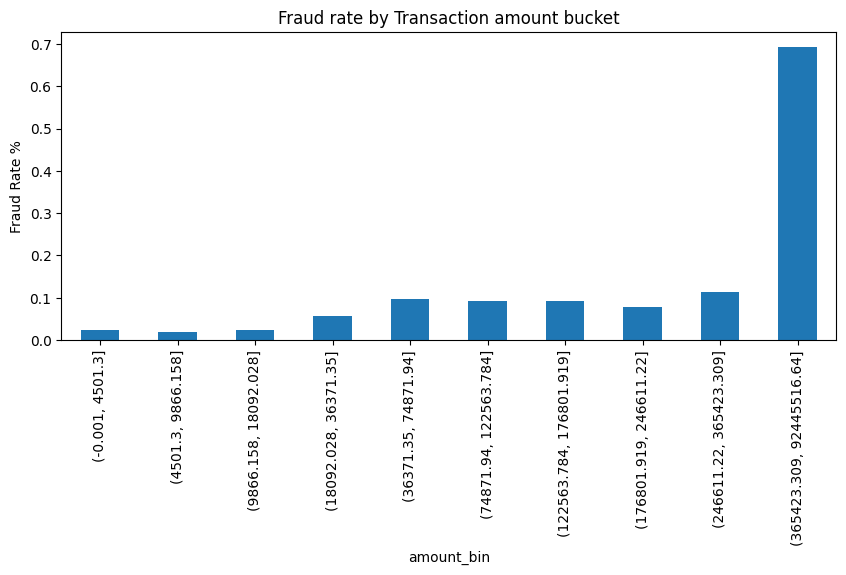

In [6]:
df['amount_bin'] = pd.qcut(df['amount'],q=10 , duplicates = 'drop')
fraud_rate = df.groupby('amount_bin')['isFraud'].mean()*100

plt.figure(figsize=(10,4))
fraud_rate.plot(kind='bar')
plt.ylabel('Fraud Rate %')
plt.title('Fraud rate by Transaction amount bucket')

plt.show()


This analysis demonstrates that transaction amount is not just a magnitude feature but a strong risk indicator, with fraud likelihood increasing significantly in higher value transaction buckets

In [7]:
df.isnull().sum()

#checking destination account for  mecrchant account starting with M
merchant_txn = df[df['nameDest'].str.startswith('M')]


In [8]:
merchant_txn.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_bin
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,"(4501.3, 9866.158]"
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,"(-0.001, 4501.3]"
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,"(9866.158, 18092.028]"
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0,0,"(4501.3, 9866.158]"
6,1,PAYMENT,7107.77,C154988899,183195.0,176087.23,M408069119,0.0,0.0,0,0,"(4501.3, 9866.158]"


In [9]:
merchant_txn[['oldbalanceDest', 'newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


the destination-balance columns do not contain useful balance information for merchant transactions.

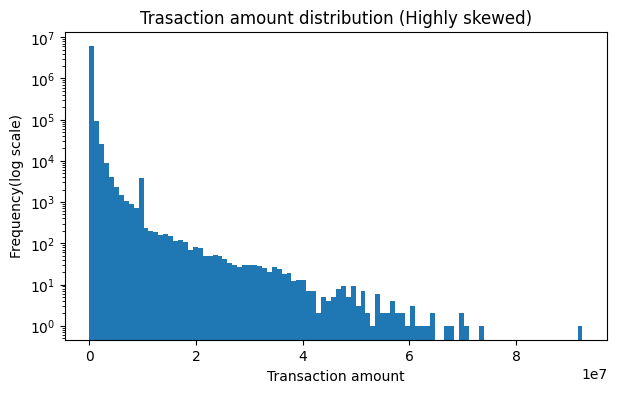

In [10]:
df['amount'].describe()

plt.figure(figsize=(7,4))
plt.hist(df['amount'],bins=100)
plt.yscale('log')
plt.ylabel('Frequency(log scale)')
plt.xlabel('Transaction amount')
plt.title('Trasaction amount distribution (Highly skewed)')
plt.show()

so from this the transaction amount is highly skewed

In [11]:
#log transaction amount to reduce skewness
df['log_amount'] = np.log1p(df['amount'])

#flag transaction for high value transaction (above 99 percentile)
p99 = df['amount'].quantile(0.99)
df['is_high_amount'] = (df['amount'] >p99).astype(int)

df['is_high_amount'].value_counts()


,count
is_high_amount,
0,6298993
1,63627


is_high_amount is the top 1 percentile of the amount which is high value

In [12]:
# overview
total_txn = len(df)
fraud_txn = df['isFraud'].sum()
fraud_rate = fraud_txn / total_txn
fraud_pct = fraud_rate *100
flagged_pct = (df['isFlaggedFraud'].sum()/total_txn) *100

print(f"Total transactions: {total_txn:,}")
print(f"Fraud transactions: {fraud_txn:,}")
print(f"Overall fraud rate: {fraud_rate:.4%}")
print(f"Fraudulent transactions (isFraud=1): {fraud_pct:.4f}%")
print(f"Flagged transactions (isFlaggedFraud=1): {flagged_pct:.4f}%")

Total transactions: 6,362,620
Fraud transactions: 8,213
Overall fraud rate: 0.1291%
Fraudulent transactions (isFraud=1): 0.1291%
Flagged transactions (isFlaggedFraud=1): 0.0003%


the fraud transaction are about 0.074% around and previously flagged transaction is 0 so this model is needed to made

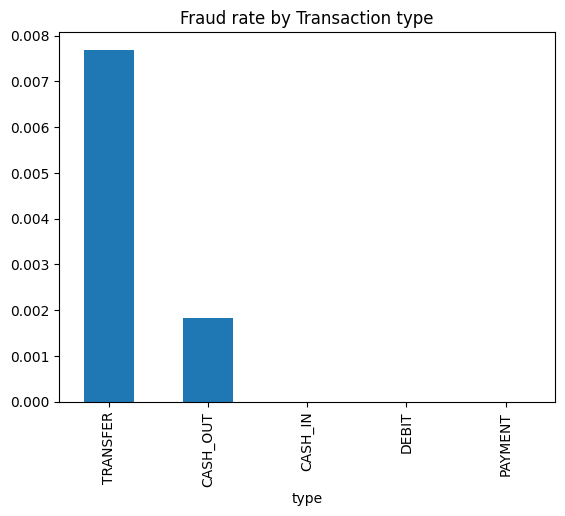

In [13]:
#Fraud rate by transaction type
df.groupby('type')['isFraud'].mean().sort_values(ascending = False).plot(kind='bar')
plt.title('Fraud rate by Transaction type')
plt.show()

,hour,total_transaction,total_fraud,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


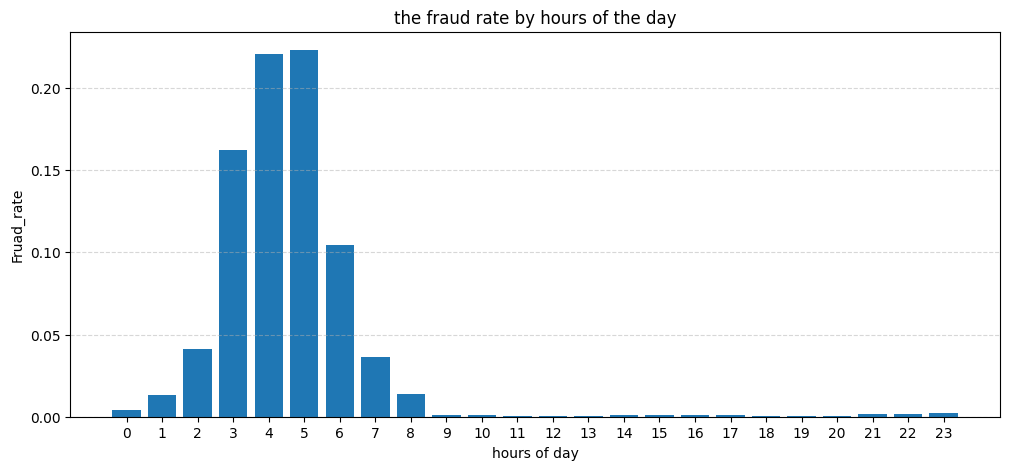

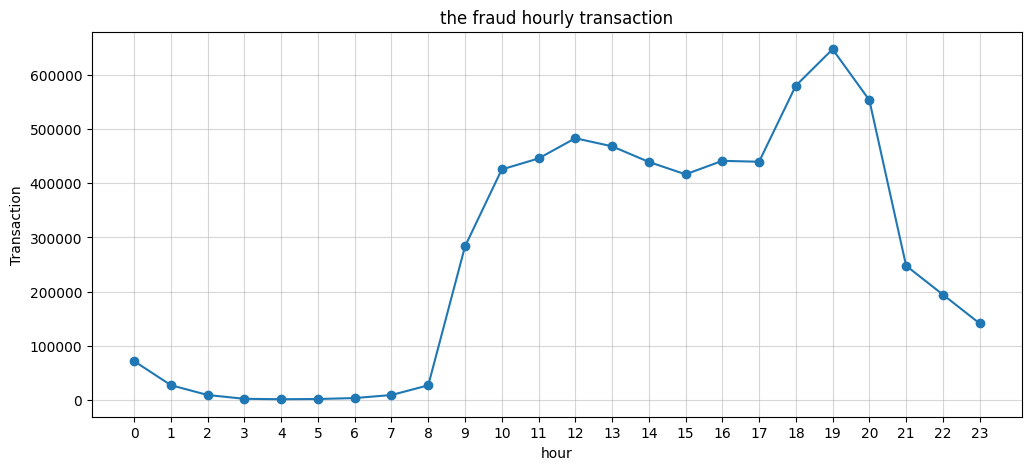

In [14]:
# time based analysis
df['hour'] = df['step']%24

# aggregate the fraud ccording to hour
hour_stats = (df.groupby('hour').agg(
          total_transaction = ('isFraud','count'),
          total_fraud = ('isFraud','sum'),
          fraud_rate = ('isFraud','mean')
          )
          .reset_index()
)
display(hour_stats.head())

#plot the fraud hourly
plt.figure(figsize=(12,5))
plt.bar(hour_stats['hour'],hour_stats['fraud_rate'])
plt.xlabel('hours of day')
plt.ylabel('Fruad_rate')
plt.title('the fraud rate by hours of the day')
plt.xticks(range(0,24))
plt.grid(axis='y' , linestyle = '--' , alpha= 0.5)
plt.show()

#fraud by transaction volunme
plt.figure(figsize=(12,5))
plt.plot(hour_stats['hour'],hour_stats['total_transaction'],marker = 'o')
plt.xlabel('hour')
plt.ylabel('Transaction')
plt.title('the fraud hourly transaction')
plt.xticks(range(0,24))
plt.grid(alpha = 0.5)
plt.show()


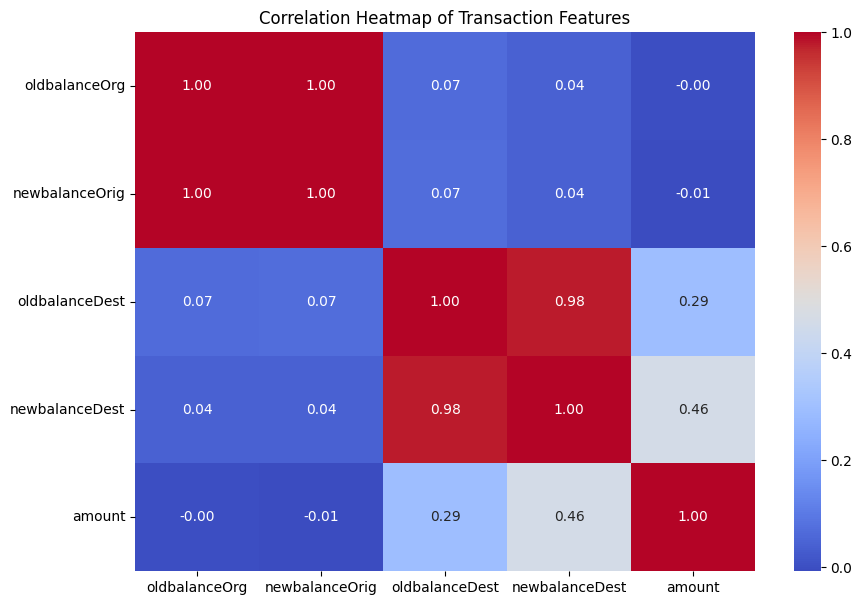

In [15]:
import seaborn as sns

plt.figure(figsize=(10,7))
corr = df[['oldbalanceOrg','newbalanceOrig',
           'oldbalanceDest','newbalanceDest',
           'amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Transaction Features')
plt.show()


The correlation matrix reveals severe multicollinearity between pre- and post-transaction balances, indicating redundancy. To address this, balance-difference features were engineered and redundant variables need to be removed, improving model stability and interpretability.

#Feature Engineering

In [16]:
#feature engineering

df['balance_diff_org'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balance_diff_des'] = df['newbalanceDest'] - df['oldbalanceDest']

# Feature Reduction (for linear models here for logistic regression)
df = df.drop(columns=[
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
])



In [17]:
df.drop(columns=['amount_bin'], inplace=True)
df.fillna(0, inplace=True)

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

df.drop(['nameOrig', 'nameDest', 'type'], axis=1, inplace=True)

#Train and Test split


In [18]:
#Train test split
X = df.drop(columns= ['isFraud','isFlaggedFraud'])
Y = df['isFraud'].values

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, stratify = Y ,random_state=42 )

scaler = RobustScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#Model Training and evaluation

In [20]:
models= {}

#logistic_regression
lr = LogisticRegression(
    max_iter = 300,
    class_weight= 'balanced',
    n_jobs = -1
)
lr.fit(X_train,Y_train)
models['logictic_regression'] = lr

#random_forest
rs = RandomForestClassifier(
    n_estimators = 50,
    max_depth = 12,
    class_weight = 'balanced',
    random_state = 42,
    min_samples_leaf = 100,
    n_jobs = -1

)
rs.fit(X_train,Y_train)
models['Random_forest_classifier'] = rs

#XG boost
xg = xgb.XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.1,
    scale_pos_weight = (Y_train == 0).sum()/(Y_train == 1).sum(),
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)
xg.fit(X_train , Y_train)
models['xgboost'] = xg


In [21]:
for name, model in models.items():
  Y_pred = model.predict(X_test)
  acc = accuracy_score(Y_test,Y_pred)

  print(name)
  print('Accuracy:',acc)
  print(classification_report(Y_test,Y_pred))
  print("-" * 40)


logictic_regression
Accuracy: 0.9591842668586211
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.88      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

----------------------------------------
Random_forest_classifier
Accuracy: 0.9812765810310847
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.96      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.55   1272524
weighted avg       1.00      0.98      0.99   1272524

----------------------------------------
xgboost
Accuracy: 0.9847649238835574
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1   

so by this result xgboost has overall good result with accuracy 99.8% but more importantly recall with 96% and precision with 8% which is better than other two

#Finding the best thershold for recall above 90% and best precsion to that


In [24]:
from sklearn.metrics import precision_recall_curve

# Get fraud probabilities
Y_scores = model.predict_proba(X_test)[:, 1]

# Get precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(Y_test, Y_scores)

# Keep thresholds where recall is at least 90%
valid = recall[:-1] >= 0.90

# Among them, choose the one with highest precision
best_index = precision[:-1][valid].argmax()

best_threshold = thresholds[valid][best_index]
best_precision = precision[:-1][valid][best_index]
best_recall = recall[:-1][valid][best_index]

print("Best Threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)


Best Threshold: 0.8730897
Precision: 0.3381344307270233
Recall: 0.9001825928180158


By above this we have the best thershold with minimum 90% recall and with 33% precsion

#Saving the Model

In [27]:
import joblib

best_model = models['xgboost']
# Save model + threshold + features
best_model_artifact = {
    "model_name": "XGBoost",
    "model": best_model,
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}

# Save everything
joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print("Saved best model: XGBoost")
print(f"Decision threshold: {best_threshold:.4f}")

Saved best model: XGBoost
Decision threshold: 0.8731


#Testing

In [30]:
# Load saved model artifact
artifact = joblib.load("best_fraud_model_tuned.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict on test data
Y_scores = model.predict_proba(X_test[features])[:, 1]
Y_pred = (Y_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "Correctly detected fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correct non-fraud (TN)"
])

print(summary)

# quick fraud recall check
print(f"\nFraud Recall: {tp / (tp + fn):.3f}")
print(f"Fraud Precision: {tp / (tp + fp):.3f}")


                                 Count
Correctly detected fraud (TP)     1479
Missed fraud (FN)                  164
False alarms (FP)                 2895
Correct non-fraud (TN)         1267986

Fraud Recall: 0.900
Fraud Precision: 0.338


At an optimized threshold, the model achieves ~90% fraud recall with ~34% precision, meaning one in three flagged transactions is truly fraudulent.

While testing correctly allowed ~1.27 million legitimate transactions.

Precision: 34% Alerts: ~29,00  
Missed fraud: only 164